# CineIQ — Exploratory Data Analysis

MovieLens 20M dataset (20M ratings, 27K movies)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

RAW = "../data/raw/ml-20m"
PROC = "../data/processed"

# Load MovieLens 20M (CSV format)
movies = pd.read_csv(f"{RAW}/movies.csv")
ratings = pd.read_csv(f"{RAW}/ratings.csv")

print(f"Movies: {len(movies):,}")
print(f"Ratings: {len(ratings):,}")
print(f"Users: {ratings['userId'].nunique():,}")
print(f"Rating range: {ratings['rating'].min()} - {ratings['rating'].max()}")

Movies: 27,278
Ratings: 20,000,263
Users: 138,493
Rating range: 0.5 - 5.0


In [2]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,2,3.5,1112486027
1,1,29,3.5,1112484676
2,1,32,3.5,1112484819
3,1,47,3.5,1112484727
4,1,50,3.5,1112484580


In [4]:
# Merge ratings with movie metadata
df = ratings.merge(movies, on="movieId")
print(f"Merged shape: {df.shape}")
df.head()

Merged shape: (20000263, 6)


,userId,movieId,rating,timestamp,title,genres
0,1,2,3.5,1112486027,Jumanji (1995),Adventure|Children|Fantasy
1,1,29,3.5,1112484676,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi
2,1,32,3.5,1112484819,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
3,1,47,3.5,1112484727,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,3.5,1112484580,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [5]:
# Save processed data
df.to_csv(f"{PROC}/merged.csv", index=False)
movies.to_csv(f"{PROC}/movies.csv", index=False)
print("Saved merged.csv and movies.csv")

Saved merged.csv and movies.csv


## Rating Distribution

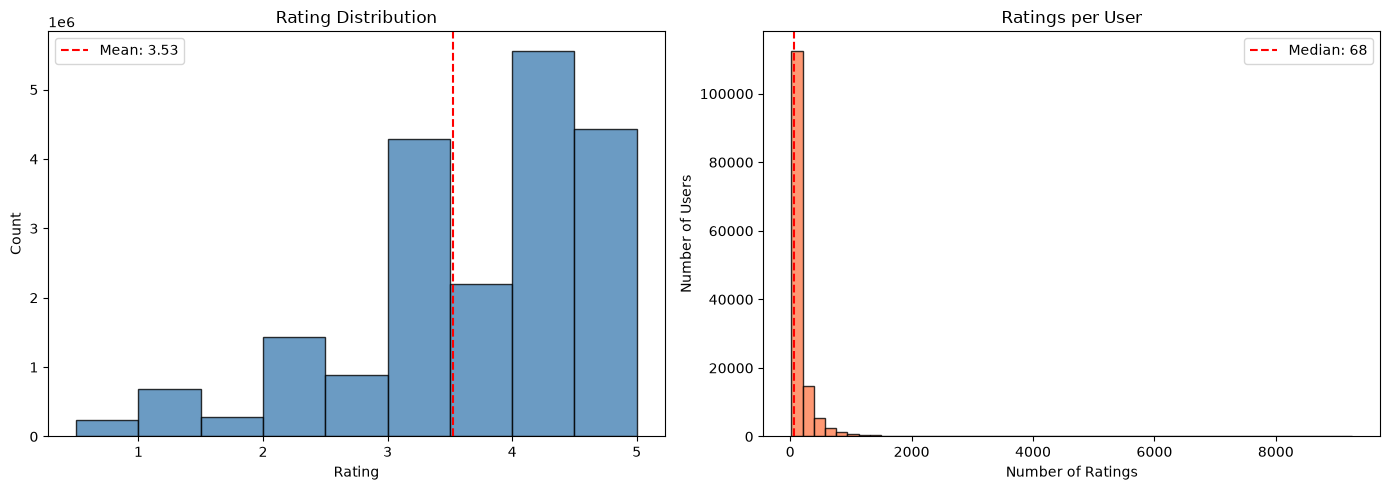

Mean rating: 3.526
Avg ratings/user: 144.4
Median ratings/user: 68


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating histogram
axes[0].hist(ratings["rating"], bins=9, edgecolor="black", color="steelblue", alpha=0.8)
axes[0].set_title("Rating Distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")
axes[0].axvline(ratings["rating"].mean(), color="red", linestyle="--", label=f'Mean: {ratings["rating"].mean():.2f}')
axes[0].legend()

# Ratings per user
user_counts = ratings.groupby("userId")["rating"].count()
axes[1].hist(user_counts, bins=50, edgecolor="black", color="coral", alpha=0.8)
axes[1].set_title("Ratings per User")
axes[1].set_xlabel("Number of Ratings")
axes[1].set_ylabel("Number of Users")
axes[1].axvline(user_counts.median(), color="red", linestyle="--", label=f'Median: {user_counts.median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean rating: {ratings['rating'].mean():.3f}")
print(f"Avg ratings/user: {user_counts.mean():.1f}")
print(f"Median ratings/user: {user_counts.median():.0f}")

## Genre Analysis

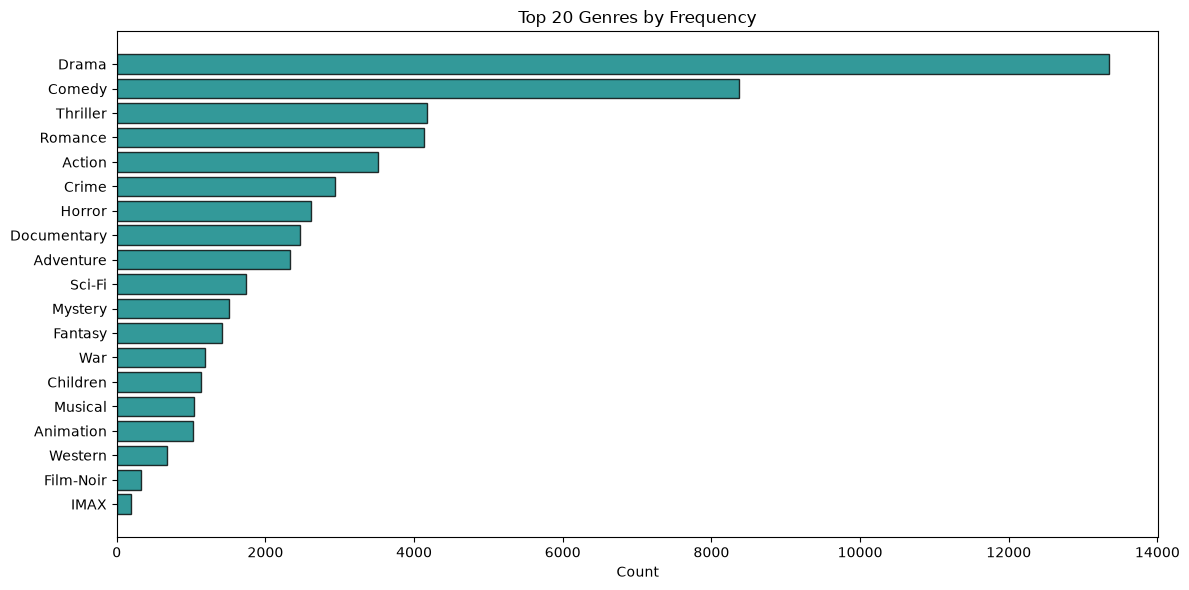

Total genres: 19


In [7]:
# Genre frequency
all_genres = []
for g in movies["genres"]:
    if g != "(no genres listed)":
        all_genres.extend(g.split("|"))

genre_counts = Counter(all_genres)
genre_df = pd.DataFrame(genre_counts.most_common(20), columns=["Genre", "Count"])

plt.figure(figsize=(12, 6))
plt.barh(genre_df["Genre"], genre_df["Count"], color="teal", alpha=0.8, edgecolor="black")
plt.xlabel("Count")
plt.title("Top 20 Genres by Frequency")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Total genres: {len(genre_counts)}")

## Movie Rating Count Distribution

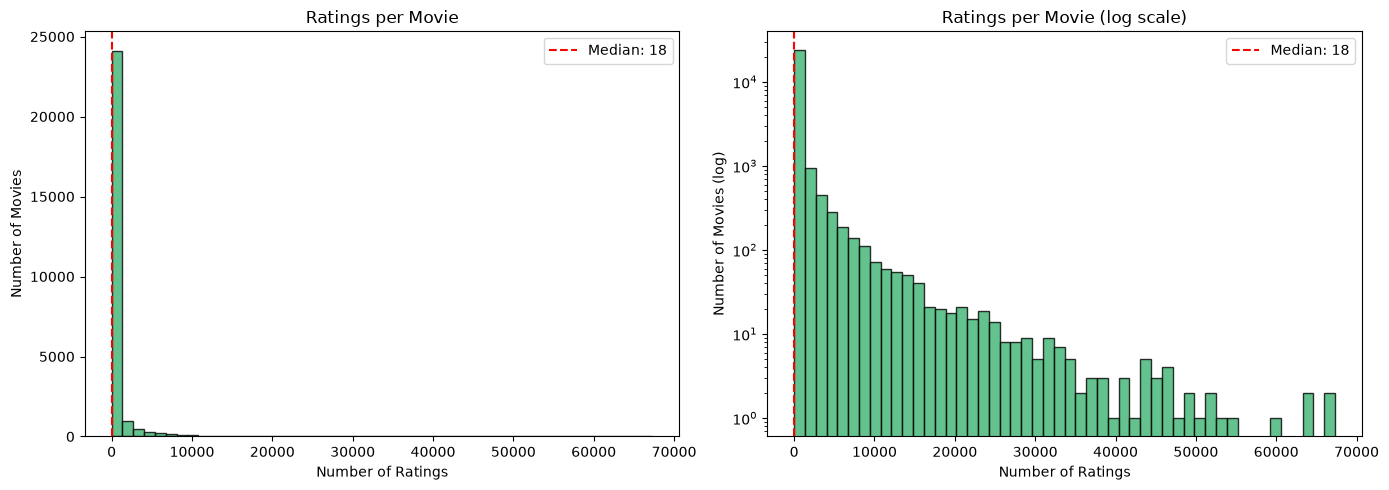

Movies: 26,744
Avg ratings/movie: 747.8
Median ratings/movie: 18
Min: 1, Max: 67310


In [8]:
movie_counts = ratings.groupby("movieId")["rating"].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(movie_counts, bins=50, edgecolor="black", color="mediumseagreen", alpha=0.8)
axes[0].set_title("Ratings per Movie")
axes[0].set_xlabel("Number of Ratings")
axes[0].set_ylabel("Number of Movies")
axes[0].axvline(movie_counts.median(), color="red", linestyle="--", label=f'Median: {movie_counts.median():.0f}')
axes[0].legend()

# Log scale
axes[1].hist(movie_counts, bins=50, edgecolor="black", color="mediumseagreen", alpha=0.8)
axes[1].set_yscale("log")
axes[1].set_title("Ratings per Movie (log scale)")
axes[1].set_xlabel("Number of Ratings")
axes[1].set_ylabel("Number of Movies (log)")
axes[1].axvline(movie_counts.median(), color="red", linestyle="--", label=f'Median: {movie_counts.median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Movies: {len(movie_counts):,}")
print(f"Avg ratings/movie: {movie_counts.mean():.1f}")
print(f"Median ratings/movie: {movie_counts.median():.0f}")
print(f"Min: {movie_counts.min()}, Max: {movie_counts.max()}")

## Sparsity

In [9]:
n_users = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()
n_ratings = len(ratings)
sparsity = 1 - (n_ratings / (n_users * n_movies))

print(f"User-Item matrix: {n_users:,} x {n_movies:,} = {n_users * n_movies:,}")
print(f"Actual ratings: {n_ratings:,}")
print(f"Sparsity: {sparsity:.4%}")

User-Item matrix: 138,493 x 26,744 = 3,703,856,792
Actual ratings: 20,000,263
Sparsity: 99.4600%
